In [1]:
pwd

'/workspace'

In [1]:
from pathlib import Path

ROOT = Path("datasets/IDD_Detection")
IMG = ROOT / "JPEGImages"
XML = ROOT / "Annotations"

train_txt = ROOT / "train.txt"
val_txt   = ROOT / "val.txt"

def check_split(txtfile):
    missing_img = 0
    missing_xml = 0
    total = 0

    with open(txtfile, "r") as f:
        for line in f:
            entry = line.strip()
            total += 1

            # exact path as official split + extension
            img_path = IMG / (entry + ".jpg")
            xml_path = XML / (entry + ".xml")

            if not img_path.exists():
                missing_img += 1
            if not xml_path.exists():
                missing_xml += 1

    print(f"\n[CHECK] {txtfile.name}")
    print(f"Total entries:     {total}")
    print(f"Missing .jpg:       {missing_img}")
    print(f"Missing .xml:       {missing_xml}")

check_split(train_txt)
check_split(val_txt)



[CHECK] train.txt
Total entries:     31569
Missing .jpg:       0
Missing .xml:       0

[CHECK] val.txt
Total entries:     10225
Missing .jpg:       0
Missing .xml:       0


In [8]:
!mkdir -p datasets/IDD_YOLO/images/train
!mkdir -p datasets/IDD_YOLO/images/val
!mkdir -p datasets/IDD_YOLO/labels/train
!mkdir -p datasets/IDD_YOLO/labels/val


In [9]:
import os
from pathlib import Path
import xml.etree.ElementTree as ET
from tqdm import tqdm
import shutil

# --------------------------------------------------------
# CONFIG
# --------------------------------------------------------
ROOT = Path("datasets/IDD_Detection")
IMG_ROOT = ROOT / "JPEGImages"
XML_ROOT = ROOT / "Annotations"
OUT_ROOT = Path("datasets/IDD_YOLO")

TRAIN_TXT = ROOT / "train.txt"
VAL_TXT   = ROOT / "val.txt"

# IDD detection classes
CLASSES = [
    "person", "rider", "car", "truck", "bus",
    "motorcycle", "bicycle", "autorickshaw",
    "animal", "traffic light", "traffic sign"
]
CLASS2ID = {c: i for i, c in enumerate(CLASSES)}

# Prepare output folders
for split in ["train", "val"]:
    (OUT_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

def load_split(path):
    items = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                items.append(line)
    return items

train_items = load_split(TRAIN_TXT)
val_items   = load_split(VAL_TXT)

print(f"[INFO] train.txt: {len(train_items)} items")
print(f"[INFO] val.txt:   {len(val_items)} items")

def convert_entry(entry, split):
    """
    entry example:
    frontFar/BLR-2018-03-22_17-39-26_2_frontFar/001542_r
    We append extension .jpg and .xml
    """

    img_path = IMG_ROOT / (entry + ".jpg")
    xml_path = XML_ROOT / (entry + ".xml")

    if not img_path.exists() or not xml_path.exists():
        return False

    # Make unique output filename
    out_name = entry.replace("/", "_") + ".jpg"

    # Copy image
    shutil.copy(str(img_path), OUT_ROOT / "images" / split / out_name)

    # Parse XML
    tree = ET.parse(str(xml_path))
    root = tree.getroot()
    W = int(root.find("size/width").text)
    H = int(root.find("size/height").text)

    yolo_lines = []
    for obj in root.findall("object"):
        cls = obj.find("name").text.strip()
        if cls not in CLASS2ID:
            continue

        cid = CLASS2ID[cls]
        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        # ----------------------------
        # SAFE BOUNDING BOX CLAMPING
        # ----------------------------
        xmin = max(0, min(xmin, W - 1))
        xmax = max(0, min(xmax, W - 1))
        ymin = max(0, min(ymin, H - 1))
        ymax = max(0, min(ymax, H - 1))

        # Remove invalid boxes
        if xmax <= xmin or ymax <= ymin:
            continue

        # Compute YOLO normalized values
        cx = (xmin + xmax) / 2 / W
        cy = (ymin + ymax) / 2 / H
        bw = (xmax - xmin) / W
        bh = (ymax - ymin) / H

        # Final sanity checks
        if not (0 <= cx <= 1 and 0 <= cy <= 1):
            continue
        if not (0 < bw <= 1 and 0 < bh <= 1):
            continue

        yolo_lines.append(f"{cid} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    # Write label file
    out_lbl = OUT_ROOT / "labels" / split / out_name.replace(".jpg", ".txt")
    with open(out_lbl, "w") as f:
        f.write("\n".join(yolo_lines))

    return True

def process_split(split, items):
    written = 0
    missing = 0
    for entry in tqdm(items, desc=f"Processing {split}"):
        if convert_entry(entry, split):
            written += 1
        else:
            missing += 1
    print(f"[RESULT] {split}: written={written}, missing={missing}")

# Run conversion
process_split("train", train_items)
process_split("val", val_items)

print("\n[DONE] Official IDD - YOLO conversion COMPLETE!")


[INFO] train.txt: 31569 items
[INFO] val.txt:   10225 items



rocessing train: 100%|██████████| 31569/31569 [02:51<00:00, 184.23it/s]

[RESULT] train: written=31569, missing=0


Processing val: 100%|██████████| 10225/10225 [00:57<00:00, 176.71it/s]

[RESULT] val: written=10225, missing=0

[DONE] Official IDD - YOLO conversion COMPLETE! (Clamped & Clean)


In [10]:
import os

train_imgs = len([f for f in os.listdir("datasets/IDD_YOLO/images/train") if f.endswith(".jpg")])
val_imgs   = len([f for f in os.listdir("datasets/IDD_YOLO/images/val")   if f.endswith(".jpg")])

print("YOLO train images:", train_imgs)
print("YOLO val images:  ", val_imgs)


YOLO train images: 31569
YOLO val images:   10225


In [11]:
import glob

LABEL_ROOT = "datasets/IDD_YOLO/labels"
valid_classes = set(range(11))
errors = 0

def check_labels(split):
    global errors
    files = glob.glob(f"{LABEL_ROOT}/{split}/*.txt")
    for f in files:
        with open(f, "r") as lf:
            for line in lf:
                parts = line.strip().split()
                if len(parts) != 5:
                    print("[FORMAT ERROR]", f, line)
                    errors += 1
                    continue

                cid, cx, cy, w, h = parts
                cid = int(cid)
                cx, cy, w, h = map(float, (cx, cy, w, h))

                if cid not in valid_classes:
                    print("[CLASS ID ERROR]", f, cid)
                    errors += 1

                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                    print("[BBOX RANGE ERROR]", f, (cx,cy,w,h))
                    errors += 1

check_labels("train")
check_labels("val")

print("\nTOTAL LABEL ERRORS:", errors)



TOTAL LABEL ERRORS: 0


In [12]:
!find datasets/IDD_YOLO/images/train -name "*.jpg" | wc -l

31569


In [13]:
!find datasets/IDD_YOLO/images/val -name "*.jpg" | wc -l

10225


In [16]:
!git clone https://github.com/ultralytics/ultralytics.git


Cloning into 'ultralytics'...
remote: Enumerating objects: 76052, done.
remote: Counting objects: 100% (328/328), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 76052 (delta 252), reused 184 (delta 166), pack-reused 75724 (from 3)
Receiving objects: 100% (76052/76052), 40.63 MiB | 17.70 MiB/s, done.
Resolving deltas: 100% (57146/57146), done.


In [17]:
%cd ultralytics
!pip install -e .


/workspace/ultralytics


/usr/local/lib/python3.12/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.13a0+0d33366-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 

In [6]:
!pip install "numpy<2" --force-reinstall


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/texttable-1.7.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.13a0+0d33366-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 

In [1]:
import numpy as np
np.__version__


'1.26.4'

In [1]:
import os
import sys

#  Set the working directory to the folder containing the top-level ultralytics package
os.chdir("/workspace")  # change to your workspace root where ultralytics folder exists
print("Current working directory:", os.getcwd())


Current working directory: /workspace


In [2]:
#  Add the top-level ultralytics folder to Python path
os.chdir("/workspace/ultralytics")
print("Current working directory:", os.getcwd())

Current working directory: /workspace/ultralytics


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
Setup complete ✅ (224 CPUs, 2015.6 GB RAM, 621.5/3515.6 GB disk)


In [6]:
from ultralytics import YOLO
import time
import torch

# === Parameters ===
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
run_name = "try"
epochs = 1                
imgsz = 1280              
batch_size = 32           
workers = 2               
device = "cuda:0" if torch.cuda.is_available() else "cpu"
cache_images = "disk"
amp = True                
save_interval = 40        
patience = 20             

# === Initialize YOLOv8n ===
model = YOLO("yolov8n.pt")

# === Start training ===
start_time = time.time()
print(f"Starting training for {epochs} epochs...\n")

results = model.train(
    data=dataset_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    workers=workers,
    device=device,
    cache=cache_images,
    name=run_name,
    save=True,
    amp=amp,
    patience=patience,
    save_period=save_interval
)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/3600:.2f} hours")


Starting training for 1 epochs...

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/datasets/IDD_YOLO/idd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=try, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [18]:
from ultralytics import YOLO
import time
import torch

# === Parameters ===
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
run_name = "try"
epochs = 1                
imgsz = 640              
batch_size = 64
workers = 8
device = "cuda:0" if torch.cuda.is_available() else "cpu"
cache_images = "disk"
amp = True                
save_interval = 40        
patience = 20             

# === Initialize YOLOv8n ===
model = YOLO("yolov8n.pt")

# === Start training ===
start_time = time.time()
print(f"Starting training for {epochs} epochs...\n")

results = model.train(
    data=dataset_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    workers=workers,
    device=device,
    cache=cache_images,
    name=run_name,
    save=True,
    amp=amp,
    patience=patience,
    save_period=save_interval
)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/3600:.2f} hours")


Starting training for 1 epochs...

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/datasets/IDD_YOLO/idd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=try, nbs=64, nms=False, opset=None, optimize=False, optimize

In [4]:
from ultralytics import YOLO
import time
import torch

# === Parameters ===
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
run_name = "yolov8n_idd_ciou_sgd"
epochs = 150                
imgsz = 640              
batch_size = 64           
workers = 8               
device = "cuda:0" if torch.cuda.is_available() else "cpu"
cache_images = "disk"
amp = True                
save_interval = 40        
patience = 20             

# === Initialize YOLOv8n ===
model = YOLO("yolov8n.pt")

# === Start training ===
start_time = time.time()
print(f"Starting training for {epochs} epochs...\n")

results = model.train(
    data=dataset_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    workers=workers,
    device=device,
    cache=cache_images,
    name=run_name,
    save=True,
    amp=amp,
    patience=patience,
    save_period=save_interval
)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/3600:.2f} hours")


Starting training for 150 epochs...

Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/datasets/IDD_YOLO/idd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_idd_ciou_sgd, nbs=64, nms=False, opset=None, opt

In [5]:
from ultralytics import YOLO
import torch
import time

# ------------------- Paths -------------------
weights = "/workspace/ultralytics/runs/detect/yolov8n_idd_ciou_sgd/weights/best.pt"
dataset_yaml = "/workspace/datasets/IDD_YOLO/idd.yaml"
results_dir = "/workspace/idd_validation"

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# ------------------- Load model -------------------
model = YOLO(weights)

# ------------------- Run Validation -------------------
print("Running validation...")

start = time.time()

model.val(
    data=dataset_yaml,
    imgsz=640,
    batch=64,
    device=device,
    project=results_dir,
    name="idd_evalv8n_ciou_sgd",
    save_json=True,
    exist_ok=True,
    verbose=True
)

end = time.time()
print(f"\nValidation completed in {end - start:.2f} seconds")
print(f"Results saved in {results_dir}/idd_eval/")


Running validation...
Ultralytics 8.3.234 🚀 Python-3.12.3 torch-2.6.0a0+df5bbc09d1.nv24.12 CUDA:0 (NVIDIA H100 80GB HBM3 MIG 3g.40gb, 40320MiB)
Model summary (fused): 72 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1178.9±421.0 MB/s, size: 489.8 KB)

val: /workspace/datasets/IDD_YOLO/images/val/highquality_16k_HYD-2018-08-24_13-02-50_0004247.jpg: 1 duplicate labels removed
val: /workspace/datasets/IDD_YOLO/images/val/highquality_16k_HYD-2018-08-24_13-22-50_0007776.jpg: 1 duplicate labels removed
val: /workspace/datasets/IDD_YOLO/images/val/highquality_16k_HYD-2018-08-24_13-22-50_0008384.jpg: 1 duplicate labels removed

                   all      10225     119936      0.704      0.414      0.469      0.302
                person       5047      18078      0.711        0.4      0.465      0.258
                 rider       6130      24517      0.736      0.464      0.527      0.305
                   car       6592      24843   


image 1/1 /workspace/0000240.jpg: 384x640 1 person, 5 cars, 3.0ms
Speed: 1.8ms preprocess, 3.0ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


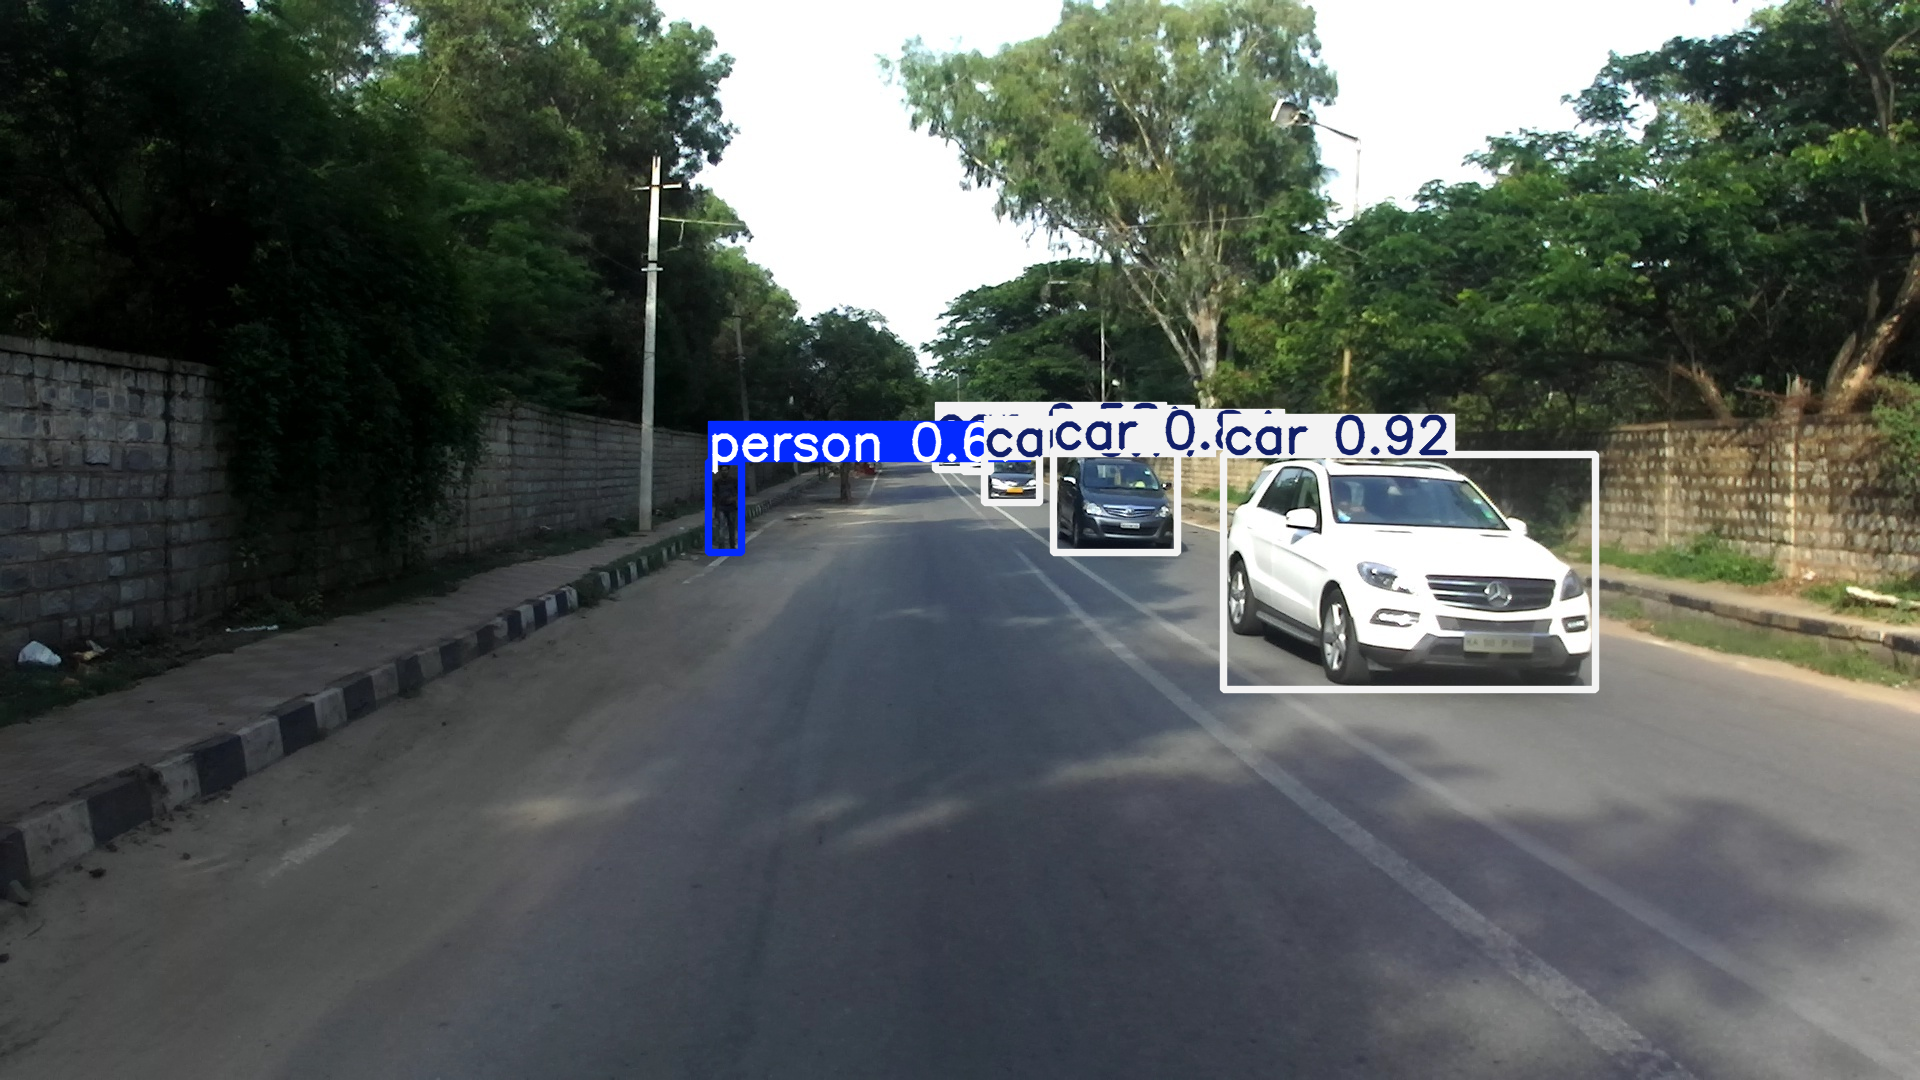

In [11]:
from ultralytics import YOLO

# Try loading and running inference with the trained model
model = YOLO("/workspace/ultralytics/runs/detect/yolov8n_idd_ciou_sgd/weights/best.pt")  # path to your trained model
results = model.predict("/workspace/0000240.jpg")  # use any sample image
results[0].show()


In [6]:
import numpy as np
import pandas as pd

# -----------------------------
# IDD CLASSES
# -----------------------------
class_names = [
    "person", "rider", "car", "truck", "bus",
    "motorcycle", "bicycle", "autorickshaw",
    "animal", "traffic light", "traffic sign"
]

# -----------------------------
# CONFUSION MATRIX (11 x 11)
# Rows = Predicted, Columns = True
# Background removed
# -----------------------------
conf_matrix = np.array([
    [6609, 280, 95, 0, 30, 3, 1, 24, 0, 8, 1149],
    [309, 10599, 106, 9, 1, 123, 1, 15, 0, 1, 1735],
    [15, 47, 13723, 136, 90, 54, 0, 96, 0, 2, 2009],
    [0, 4, 87, 3504, 216, 2, 0, 170, 0, 1, 621],
    [0, 0, 87, 108, 2771, 0, 0, 6, 0, 2, 367],
    [102, 161, 141, 3, 5, 13940, 67, 9, 10, 0, 2460],
    [0, 1, 0, 2, 23, 0, 139, 0, 0, 0, 70],
    [9, 17, 84, 143, 8, 7, 0, 4367, 2, 0, 603],
    [3, 0, 0, 0, 0, 2, 0, 0, 177, 0, 52],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 101, 21],
    [0, 1, 0, 1, 1, 0, 0, 0, 0, 2, 862]
])

# -----------------------------
# YOLO PER-CLASS METRICS
# -----------------------------
per_class_precision = [
    0.711, 0.736, 0.753, 0.701, 0.781,
    0.740, 0.577, 0.753, 0.649, 0.728, 0.613
]

per_class_recall = [
    0.400, 0.464, 0.579, 0.538, 0.601,
    0.577, 0.299, 0.591, 0.145, 0.132, 0.230
]

per_class_map50 = [
    0.465, 0.527, 0.641, 0.593, 0.667,
    0.627, 0.330, 0.653, 0.189, 0.196, 0.272
]

per_class_map5095 = [
    0.258, 0.305, 0.450, 0.425, 0.510,
    0.377, 0.194, 0.469, 0.093, 0.0937, 0.142
]

# -----------------------------
# COMPUTE PER-CLASS METRICS
# -----------------------------
metrics_data = []
total_samples = np.sum(conf_matrix)

for i, cname in enumerate(class_names):
    TP = conf_matrix[i, i]
    FP = np.sum(conf_matrix[i, :]) - TP
    FN = np.sum(conf_matrix[:, i]) - TP
    TN = total_samples - (TP + FP + FN)

    P = per_class_precision[i]
    R = per_class_recall[i]
    F1 = 2 * P * R / (P + R) if (P + R) else 0

    metrics_data.append({
        "Class": cname,
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN),
        "Precision": round(P, 4),
        "Recall": round(R, 4),
        "F1 Score": round(F1, 4),
        "Accuracy": round((TP + TN) / total_samples, 4),
        "FPR": round(FP / (FP + TN), 4),
        "FNR": round(FN / (FN + TP), 4),
        "mAP@0.5": per_class_map50[i],
        "mAP@0.5:0.95": per_class_map5095[i]
    })

# -----------------------------
# OVERALL ROW
# -----------------------------
TP_total = sum(row["TP"] for row in metrics_data)
FP_total = sum(row["FP"] for row in metrics_data)
FN_total = sum(row["FN"] for row in metrics_data)
TN_total = sum(row["TN"] for row in metrics_data)

overall = {
    "Class": "Overall",
    "TP": TP_total,
    "FP": FP_total,
    "FN": FN_total,
    "TN": TN_total,
    "Precision": round(np.mean([row["Precision"] for row in metrics_data]), 4),
    "Recall": round(np.mean([row["Recall"] for row in metrics_data]), 4),
    "F1 Score": round(np.mean([row["F1 Score"] for row in metrics_data]), 4),
    "Accuracy": round(np.mean([row["Accuracy"] for row in metrics_data]), 4),
    "FPR": round(np.mean([row["FPR"] for row in metrics_data]), 4),
    "FNR": round(np.mean([row["FNR"] for row in metrics_data]), 4),
    "mAP@0.5": round(np.mean([row["mAP@0.5"] for row in metrics_data]), 4),
    "mAP@0.5:0.95": round(np.mean([row["mAP@0.5:0.95"] for row in metrics_data]), 4)
}

metrics_data.append(overall)

# -----------------------------
# SAVE CSV
# -----------------------------
df = pd.DataFrame(metrics_data)
df.to_csv("idd_metrics_v8nciousgd.csv", index=False)
print(df)


            Class     TP     FP     FN      TN  Precision  Recall  F1 Score  \
0          person   6609   1590    438   60175     0.7110  0.4000    0.5120   
1           rider  10599   2300    511   55402     0.7360  0.4640    0.5692   
2             car  13723   2449    600   52040     0.7530  0.5790    0.6546   
3           truck   3504   1101    402   63805     0.7010  0.5380    0.6088   
4             bus   2771    570    374   65097     0.7810  0.6010    0.6793   
5      motorcycle  13940   2958    191   51723     0.7400  0.5770    0.6484   
6         bicycle    139     96     69   68508     0.5770  0.2990    0.3939   
7    autorickshaw   4367    873    320   63252     0.7530  0.5910    0.6622   
8          animal    177     57     12   68566     0.6490  0.1450    0.2370   
9   traffic light    101     21     16   68674     0.7280  0.1320    0.2235   
10   traffic sign    862      5   9087   58858     0.6130  0.2300    0.3345   
11        Overall  56792  12020  12020  676100     0

In [8]:
# ==============================================================
# YOLOv8 Speed Benchmark (H100 / MIG Safe)
# Resolution: 640 x 640
# Batch size: 1
# Metrics:
#   - Pure Inference Time (ms/frame)
#   - Inference FPS
#   - End-to-End Latency (ms/frame)
#   - Latency FPS
#   - Model Parameters (M)
#   - Model File Size (MB)
# ==============================================================

import torch
import cv2
import csv
import os
from pathlib import Path
from ultralytics import YOLO

# -----------------------------
# CONFIGURATION
# -----------------------------
weights = "/workspace/ultralytics/runs/detect/yolov8n_idd_ciou_sgd/weights/best.pt"          # Path to trained YOLOv8 model
img_path = "/workspace/0000240.jpg"      # Any validation image
img_size = 640
batch_size = 1
csv_file = "benchmark_results_v8nciousgd.csv"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------
# DEVICE INFO
# -----------------------------
print(f"\nUsing device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"cuDNN Version: {torch.backends.cudnn.version()}\n")

# -----------------------------
# LOAD MODEL
# -----------------------------
model = YOLO(weights).to(device)
model.model.eval()

model_name = Path(weights).stem
model_size_mb = Path(weights).stat().st_size / (1024 ** 2)

params = sum(p.numel() for p in model.model.parameters())
params_million = params / 1e6

print(f"Model: {model_name}")
print(f"Parameters: {params_million:.2f} M")
print(f"Model file size: {model_size_mb:.2f} MB\n")

# ==============================================================
# 1️ PURE INFERENCE SPEED (FORWARD PASS ONLY)
# ==============================================================

dummy_input = torch.randn(
    batch_size, 3, img_size, img_size, device=device
) / 255.0

# Warm-up
for _ in range(10):
    _ = model.model(dummy_input)

torch.cuda.synchronize()

starter = torch.cuda.Event(enable_timing=True)
ender = torch.cuda.Event(enable_timing=True)

n_runs = 100

starter.record()
with torch.inference_mode():
    for _ in range(n_runs):
        _ = model.model(dummy_input)
ender.record()

torch.cuda.synchronize()

inference_time_ms = starter.elapsed_time(ender) / n_runs
inference_fps = 1000 / inference_time_ms

print("=== Pure Inference (Forward Pass Only) ===")
print(f"Inference Time:  {inference_time_ms:.2f} ms/frame")
print(f"Inference Speed: {inference_fps:.2f} FPS @ {img_size}x{img_size}\n")

# ==============================================================
# 2️ END-TO-END LATENCY (PRE + INFER + POST)
# ==============================================================

img = cv2.imread(img_path)
assert img is not None, "Failed to load image."

# Warm-up
for _ in range(5):
    _ = model.predict(
        img, imgsz=img_size, device=device, verbose=False
    )

torch.cuda.synchronize()

starter.record()
for _ in range(30):
    _ = model.predict(
        img, imgsz=img_size, device=device, verbose=False
    )
ender.record()

torch.cuda.synchronize()

latency_ms = starter.elapsed_time(ender) / 30
latency_fps = 1000 / latency_ms

print("=== End-to-End Latency (Full Pipeline) ===")
print(f"Latency:     {latency_ms:.2f} ms/frame")
print(f"Latency FPS:{latency_fps:.2f}\n")

# ==============================================================
# 3️ SAVE RESULTS TO CSV
# ==============================================================

fieldnames = [
    "Model",
    "GPU",
    "Batch_Size",
    "Image_Size",
    "Params_(M)",
    "Model_Size_(MB)",
    "Inference_Time_(ms)",
    "Inference_FPS",
    "Latency_(ms)",
    "Latency_FPS",
]

file_exists = os.path.isfile(csv_file)

with open(csv_file, mode="a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not file_exists:
        writer.writeheader()

    writer.writerow({
        "Model": model_name,
        "GPU": torch.cuda.get_device_name(0),
        "Batch_Size": batch_size,
        "Image_Size": f"{img_size}x{img_size}",
        "Params_(M)": round(params_million, 2),
        "Model_Size_(MB)": round(model_size_mb, 2),
        "Inference_Time_(ms)": round(inference_time_ms, 2),
        "Inference_FPS": round(inference_fps, 2),
        "Latency_(ms)": round(latency_ms, 2),
        "Latency_FPS": round(latency_fps, 2),
    })

print(f"Benchmark results saved to: {csv_file}")

# ==============================================================
# SUMMARY
# ==============================================================
print("\n=== Benchmark Summary ===")
print(f"Model:            {model_name}")
print(f"GPU:              {torch.cuda.get_device_name(0)} (MIG Enabled)")
print(f"Input Resolution: {img_size}x{img_size}")
print(f"Batch Size:       {batch_size}")
print(f"Parameters:       {params_million:.2f} M")
print(f"Model Size:       {model_size_mb:.2f} MB")
print(f"Inference Time:   {inference_time_ms:.2f} ms ({inference_fps:.2f} FPS)")
print(f"Latency:          {latency_ms:.2f} ms ({latency_fps:.2f} FPS)")
print("=============================================================")



Using device: cuda:0
GPU: NVIDIA H100 80GB HBM3 MIG 3g.40gb
CUDA Version: 12.6
cuDNN Version: 90600

Model: best
Parameters: 3.01 M
Model file size: 5.96 MB

=== Pure Inference (Forward Pass Only) ===
Inference Time:  2.78 ms/frame
Inference Speed: 360.10 FPS @ 640x640

=== End-to-End Latency (Full Pipeline) ===
Latency:     5.44 ms/frame
Latency FPS:183.70

Benchmark results saved to: benchmark_results_v8nciousgd.csv

=== Benchmark Summary ===
Model:            best
GPU:              NVIDIA H100 80GB HBM3 MIG 3g.40gb (MIG Enabled)
Input Resolution: 640x640
Batch Size:       1
Parameters:       3.01 M
Model Size:       5.96 MB
Inference Time:   2.78 ms (360.10 FPS)
Latency:          5.44 ms (183.70 FPS)


In [9]:
import shutil

# Specify the folder path and the destination zip file path
folder_path = '/workspace/idd_validation'
zip_file_path = '/workspace/idd_validation.zip'

# Create a zip file from the folder
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

'/workspace/idd_validation.zip'

In [10]:
import shutil

# Specify the folder path and the destination zip file path
folder_path = '/workspace/ultralytics/runs/detect'
zip_file_path = '/workspace/ultralytics/runs/detect.zip'

# Create a zip file from the folder
shutil.make_archive(zip_file_path.replace('.zip', ''), 'zip', folder_path)

'/workspace/ultralytics/runs/detect.zip'